In [238]:
from sklearn.datasets import load_diabetes
from sklearn.metrics import r2_score
import numpy as np

In [239]:
X,y = load_diabetes(return_X_y=True)

In [240]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=35)

In [241]:
from sklearn.linear_model import Ridge

In [242]:
r = Ridge(alpha=0.01,solver='cholesky')
r.fit(X_train,y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",0.01
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'cholesky'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",N

In [243]:
y_pred = r.predict(X_test)
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.4587779622907331

In [244]:
print(r.coef_)
print(r.intercept_)

[ -21.99846572 -218.68927899  527.32905275  317.17060702 -458.2765415
  187.61996352  -20.64531425  178.13501751  653.27673483   62.95938835]
151.98587415125525


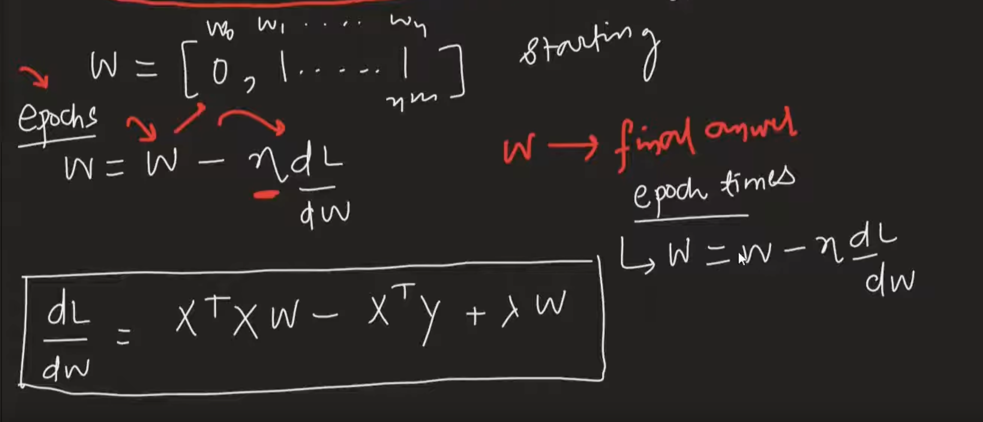

In [245]:
from PIL import Image
rgd = Image.open("rgd.png")
rgd = rgd.resize((int(rgd.width*0.5),int(rgd.height*0.5)))
rgd

In [246]:
class MyRidge:
    def __init__(self, epochs ,learning_rate, alpha=0.1):
        self.alpha = alpha
        self.m = None
        self.b = None
        self.epochs = epochs
        self.learning_rate = learning_rate


    def fit(self,X_train,y_train):

        self.m = np.ones(X_train.shape[1])
        self.b = 0
        W = np.insert(self.m,0,self.b)
        X_train = np.insert(X_train,0,1,axis=1)

        for i in range(self.epochs):

            W_der = np.dot(X_train.T,X_train).dot(W) - np.dot(X_train.T,y_train) + np.dot(self.alpha,W)
            W = W - self.learning_rate * W_der
        self.m = W[1:]
        self.b = W[0]

    def predict(self,X_test):
        return np.dot(X_test,self.m) + self.b

In [247]:
# W/L/Thetha

In [248]:
# #Eg. [1, 5, 4] @ [10, 2, 3]
#     1×10 + 5×2 + 4×3
#       = 10 + 10 + 12
#            = 32

In [249]:
mr = MyRidge(epochs=1000,learning_rate = 0.001,alpha=0.001)
mr.fit(X_train,y_train)

In [250]:
y_pred = mr.predict(X_test)

In [251]:
r2_score(y_test,y_pred)

0.4399787375917559

In [252]:
print(mr.m)
print(mr.b)

[  43.09667204  -69.32441605  364.71495773  227.63179358    9.80881639
  -31.77660225 -188.64232867  154.64758223  305.50750903  132.3396361 ]
152.15212563816823
